Author: Raptopoulos Petros

This notebooks tries to apply machine learning approaches to LLM outputs for ContractNLI experiments. In this way, I tried to find the correlation between the LLMs' outputs and if there is a way to combine their performance.

The files with the results of the ContractNLI experiments can be found at /Experiments and Evaluation/Quantitative/Classification Performance - ContractNLI/results. Put the files you are interested in a ./inputs directory.
Below are some experiments made with a subeset of the results:

In [4]:
import json

# Load the JSON file
with open('inputs/resultsLOCAL.json', 'r') as file:
    data_local = json.load(file)

# Load the JSON file - resultsOPENAI
with open('inputs/resultsOPENAI.json', 'r') as file_openai:
    data_openai = json.load(file_openai)  # Also a list of dicts

with open('inputs/resultsBEDROCK.json', 'r') as file_bedrock:
    data_bedrock = json.load(file_bedrock)  # Also a list of dicts

data = data_local + data_openai + data_bedrock

# Now 'data' is a list of dictionaries
# Let's access the first entry as an example
first_entry = data[0]

# Access accuracy
accuracy = first_entry["result"]["accuracy"]
print(f"Accuracy: {accuracy}")

# Access model name
model = first_entry["additional_info"]["model"]
print(f"Model: {model}")

# Access predictions
predictions = first_entry["result"]["predictions"]
print(f"First 5 predictions: {predictions[:5]}")

Accuracy: 0.4868483978957437
Model: Meta-Llama-3-8B-LOCAL
First 5 predictions: [1, 1, 1, 1, 2]


In [3]:
print("Total number of experiments: ", len(data))

Total number of experiments:  113


In [5]:
import pandas as pd
df = pd.json_normalize(data)
df = df.drop(columns=["result.predictions"], errors="ignore")

# if subset name isnt set, contractnli_b is the default
df["additional_info.subset_name"] = df["additional_info.subset_name"].fillna("contractnli_b")

print(df.to_markdown(index=True))

|     |   result.accuracy |   result.f1_weighted |   result.f1_per_class.contradiction |   result.f1_per_class.entailment |   result.f1_per_class.neutral | additional_info.start_timestamp   | additional_info.end_timestamp   |   additional_info.duration_seconds | additional_info.model               | additional_info.API   | additional_info.quantization   | additional_info.prompting_technique                          |   additional_info.try | additional_info.subset_name   |
|----:|------------------:|---------------------:|------------------------------------:|---------------------------------:|------------------------------:|:----------------------------------|:--------------------------------|-----------------------------------:|:------------------------------------|:----------------------|:-------------------------------|:-------------------------------------------------------------|----------------------:|:------------------------------|
|   0 |          0.486848 |             0.4612

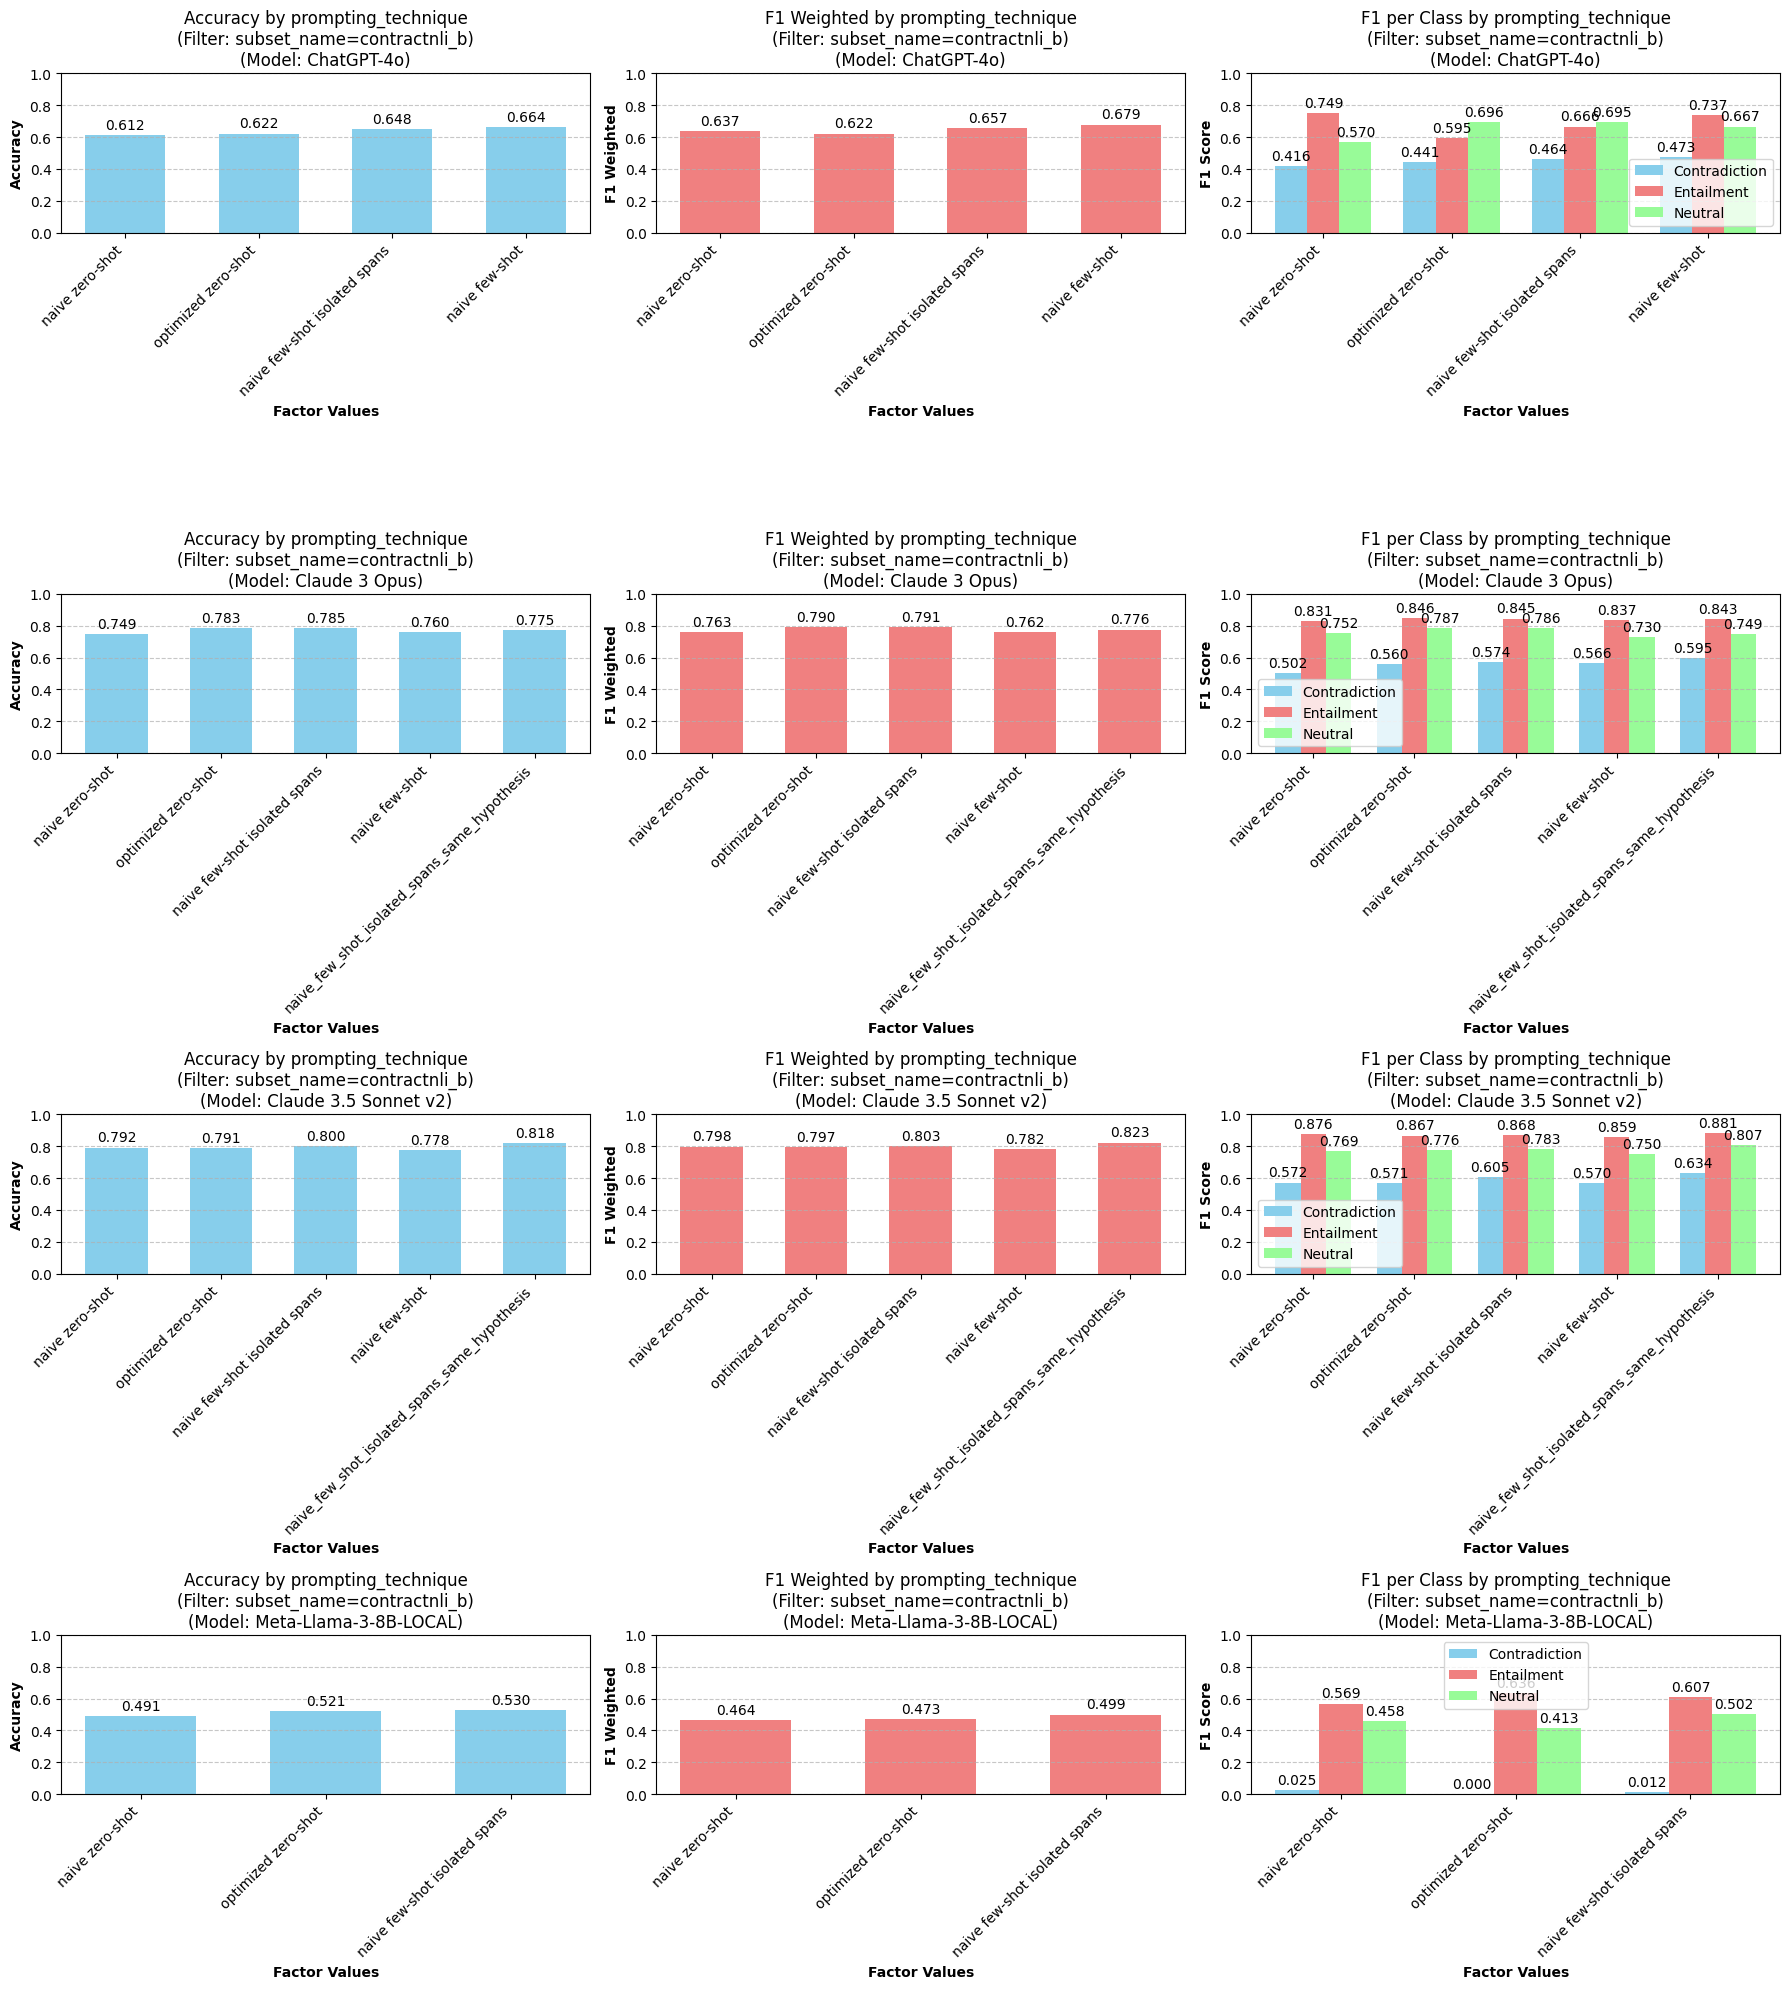

In [4]:
from MachineLearning.plotting import plot_metrics

plot_metrics(
    df,
    group_by_column="additional_info.prompting_technique",
    filter_dict={"additional_info.subset_name": "contractnli_b"},
    model_filter=["Meta-Llama-3-8B-LOCAL", "ChatGPT-4o", "Claude 3 Opus", "Claude 3.5 Sonnet v2"]
)

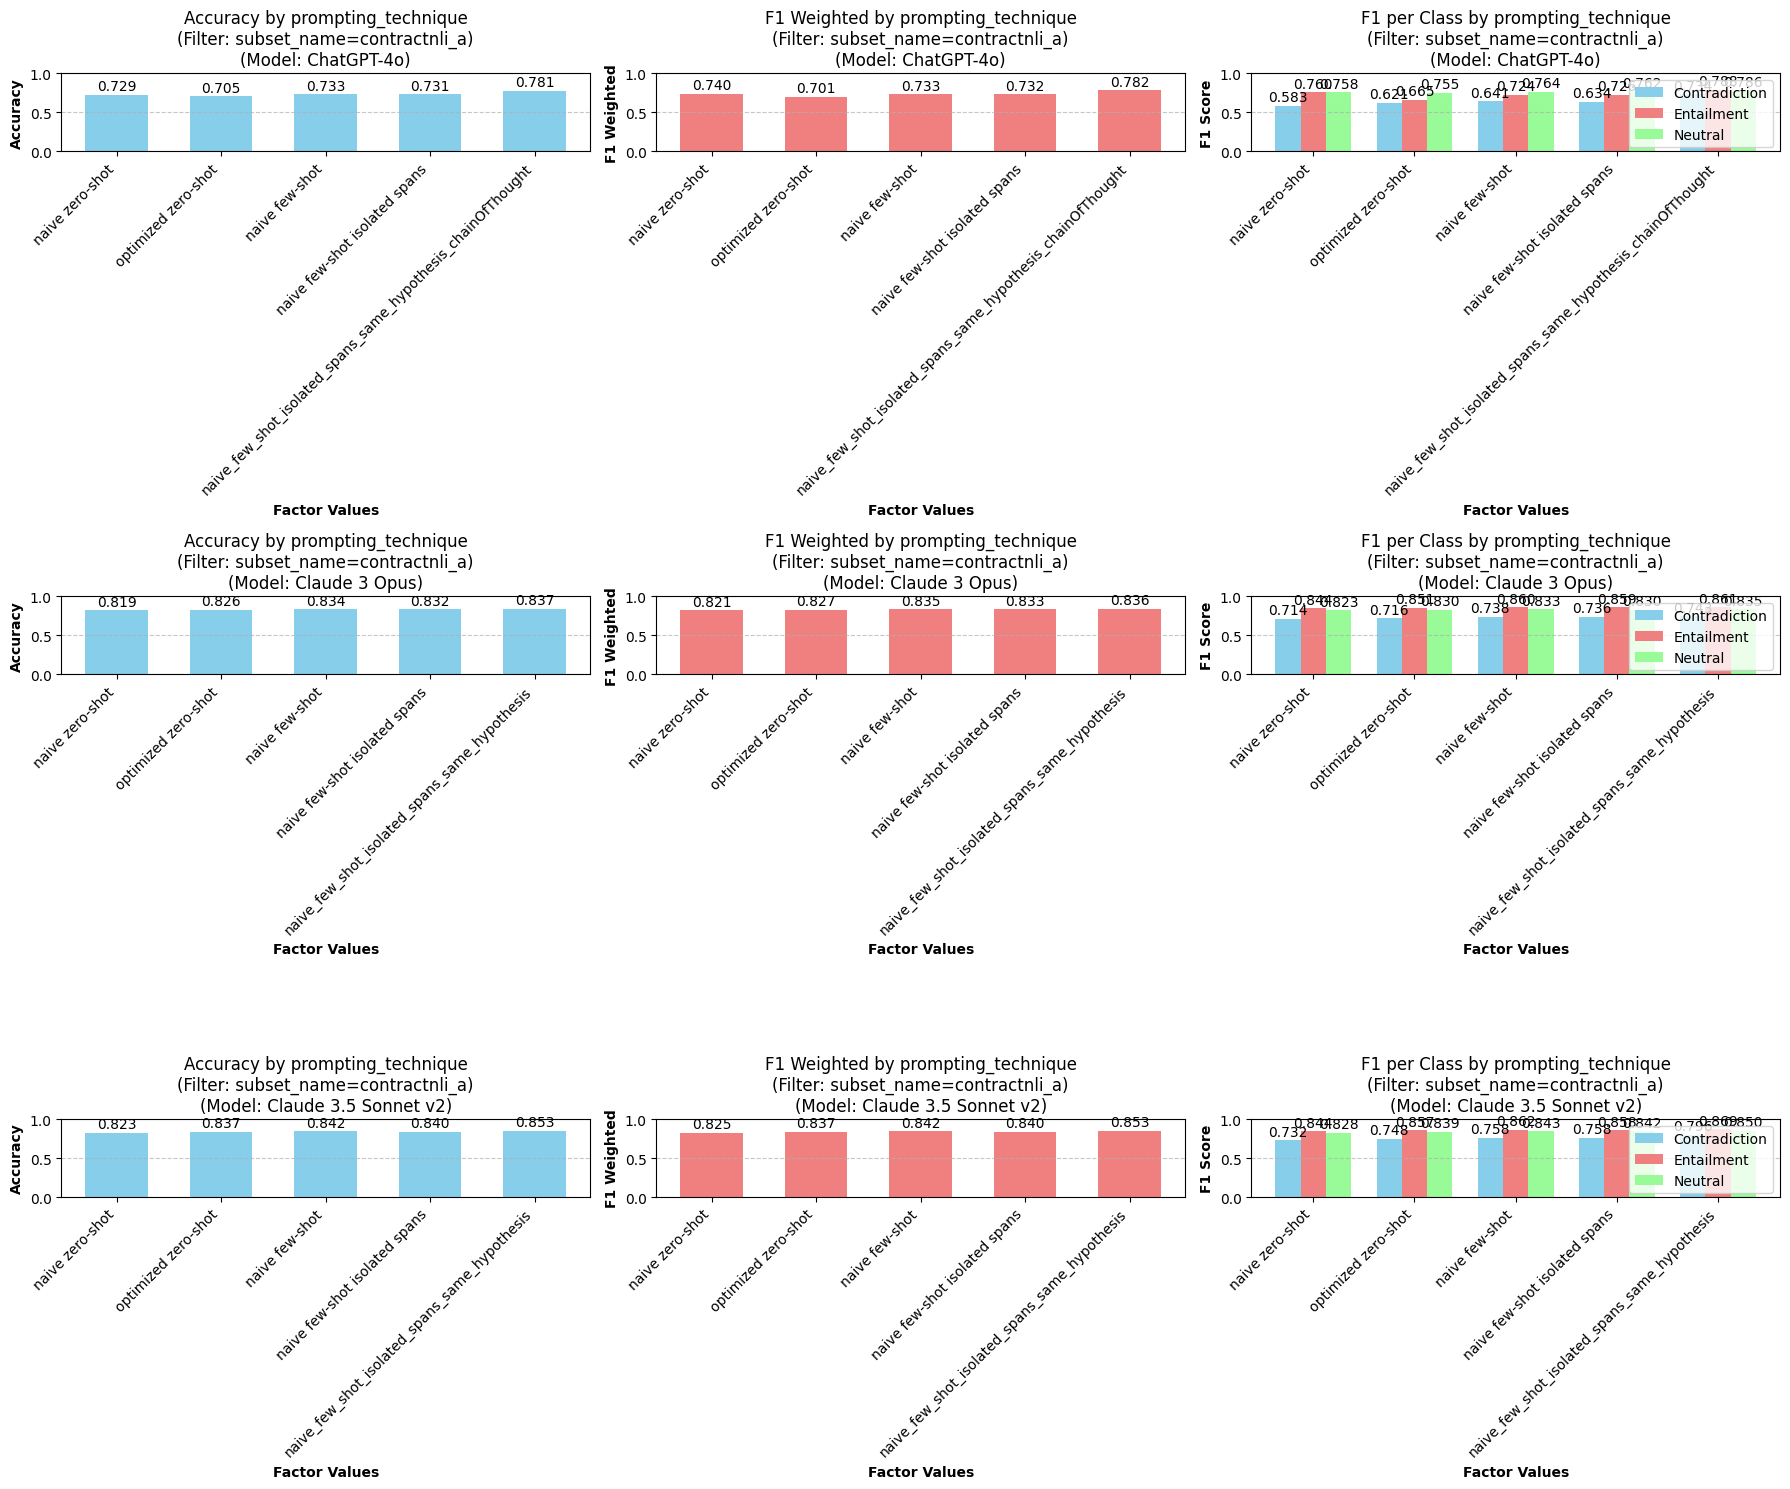

In [14]:
from MachineLearning.plotting import plot_metrics

plot_metrics(
    df,
    group_by_column="additional_info.prompting_technique",
    filter_dict={"additional_info.subset_name": "contractnli_a"},
    model_filter=["ChatGPT-4o", "Claude 3 Opus", "Claude 3.5 Sonnet v2"]
)

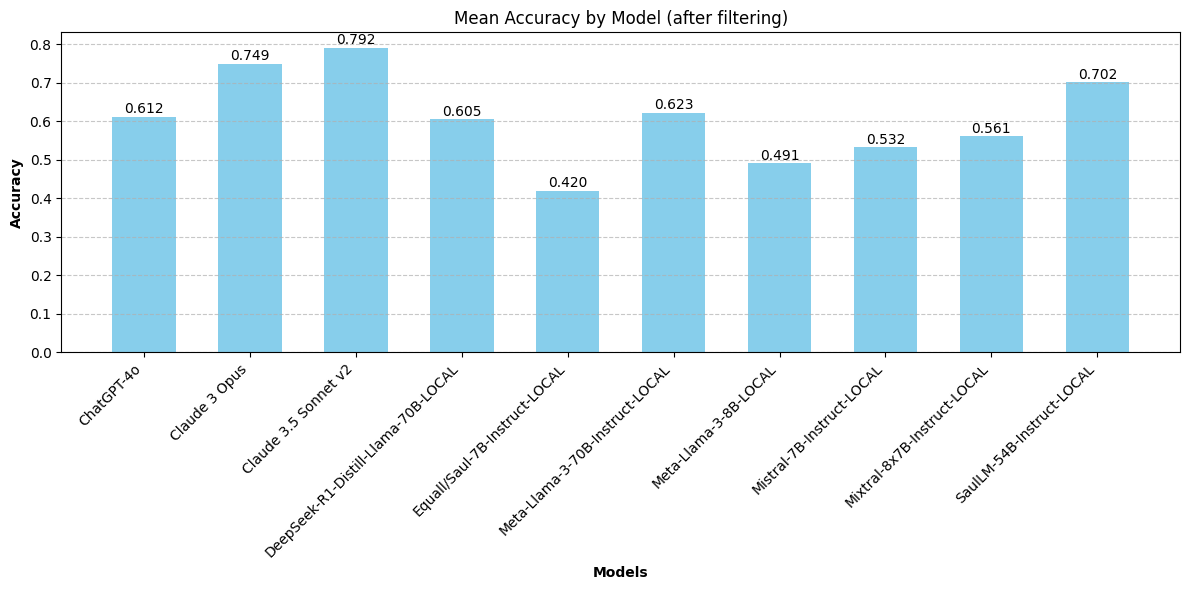

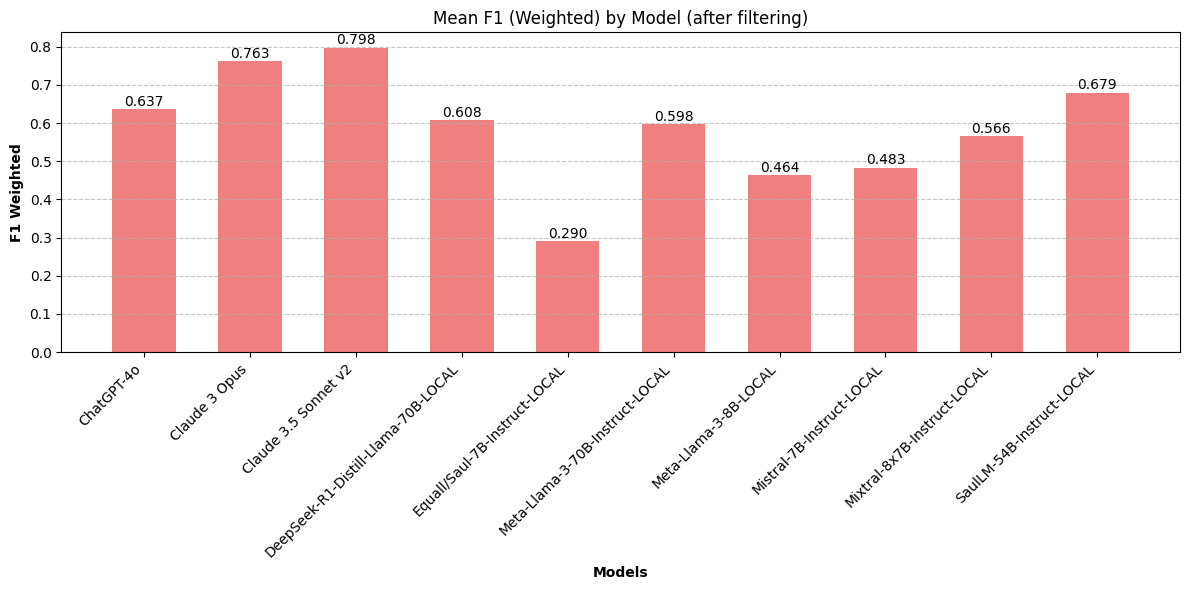

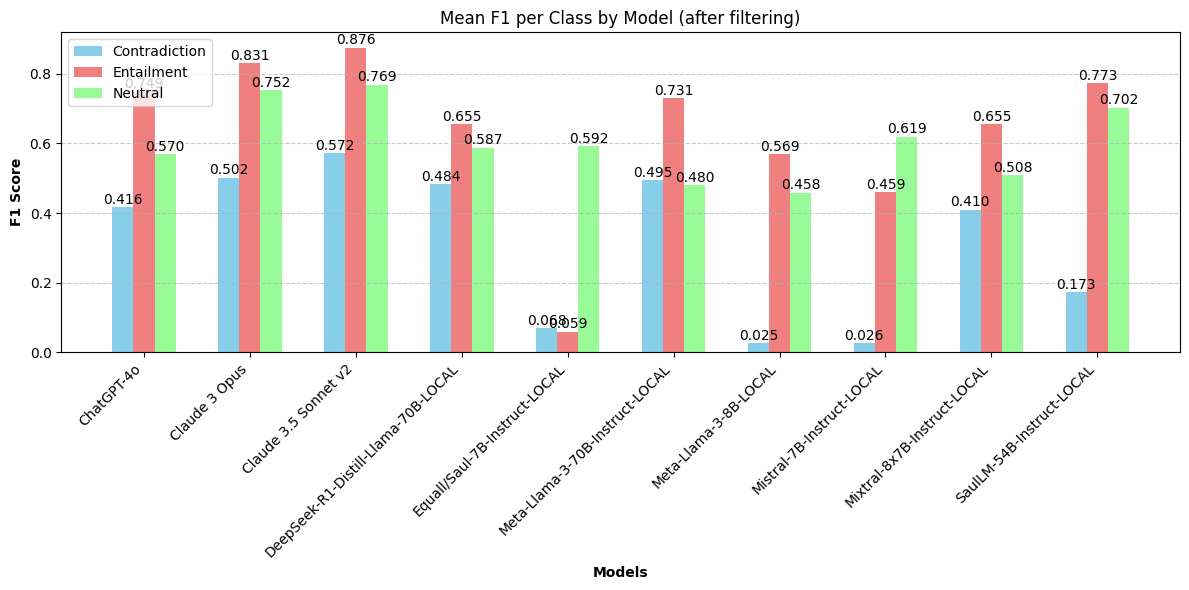

In [4]:
# from MachineLearning import plot_metrics_for_filter

from MachineLearning.plotting import plot_metrics_for_filter

plot_metrics_for_filter(df, filter_dict={
    "additional_info.prompting_technique": "naive zero-shot",
    "additional_info.subset_name": "contractnli_b"
})

In [5]:
from datasets import load_dataset

# Load the dataset
print("Loading dataset...")
dataset = load_dataset("kiddothe2b/contract-nli", "contractnli_b")
correct_labels = dataset["test"]['label']

/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...


In [6]:
corr_value = pd.Series(data[5]["result"]["predictions"]).corr(pd.Series(data[18]["result"]["predictions"]))
print("Correlation (pandas):", corr_value)

Correlation (pandas): 0.38767388396436137


In [9]:
preds_dict = {}
name_map = {} 

for index, row in enumerate(data):
    subset_name = row["additional_info"].get("subset_name", None)
    if (not subset_name or subset_name == 'contractnli_b') and row["additional_info"]["prompting_technique"] == 'naive zero-shot':  # only for subset_a 
        long_name = (
            row["additional_info"]["model"] + " - " +
            row["additional_info"]["API"] + " - " +
            row["additional_info"]["quantization"] + " - " +
            str(row["additional_info"]["prompting_technique"]) + " - " +
            str(row["additional_info"]["try"])
        )
        short_name = f"experiment_{index}"
        
        # Store the mapping
        name_map[short_name] = long_name
        
        # Add to preds_dict
        preds_dict[short_name] = row["result"]["predictions"]
        

preds_dict["ground_truth"] = correct_labels

# Create DataFrame where each column is "experiment_n"
df_preds = pd.DataFrame(preds_dict)

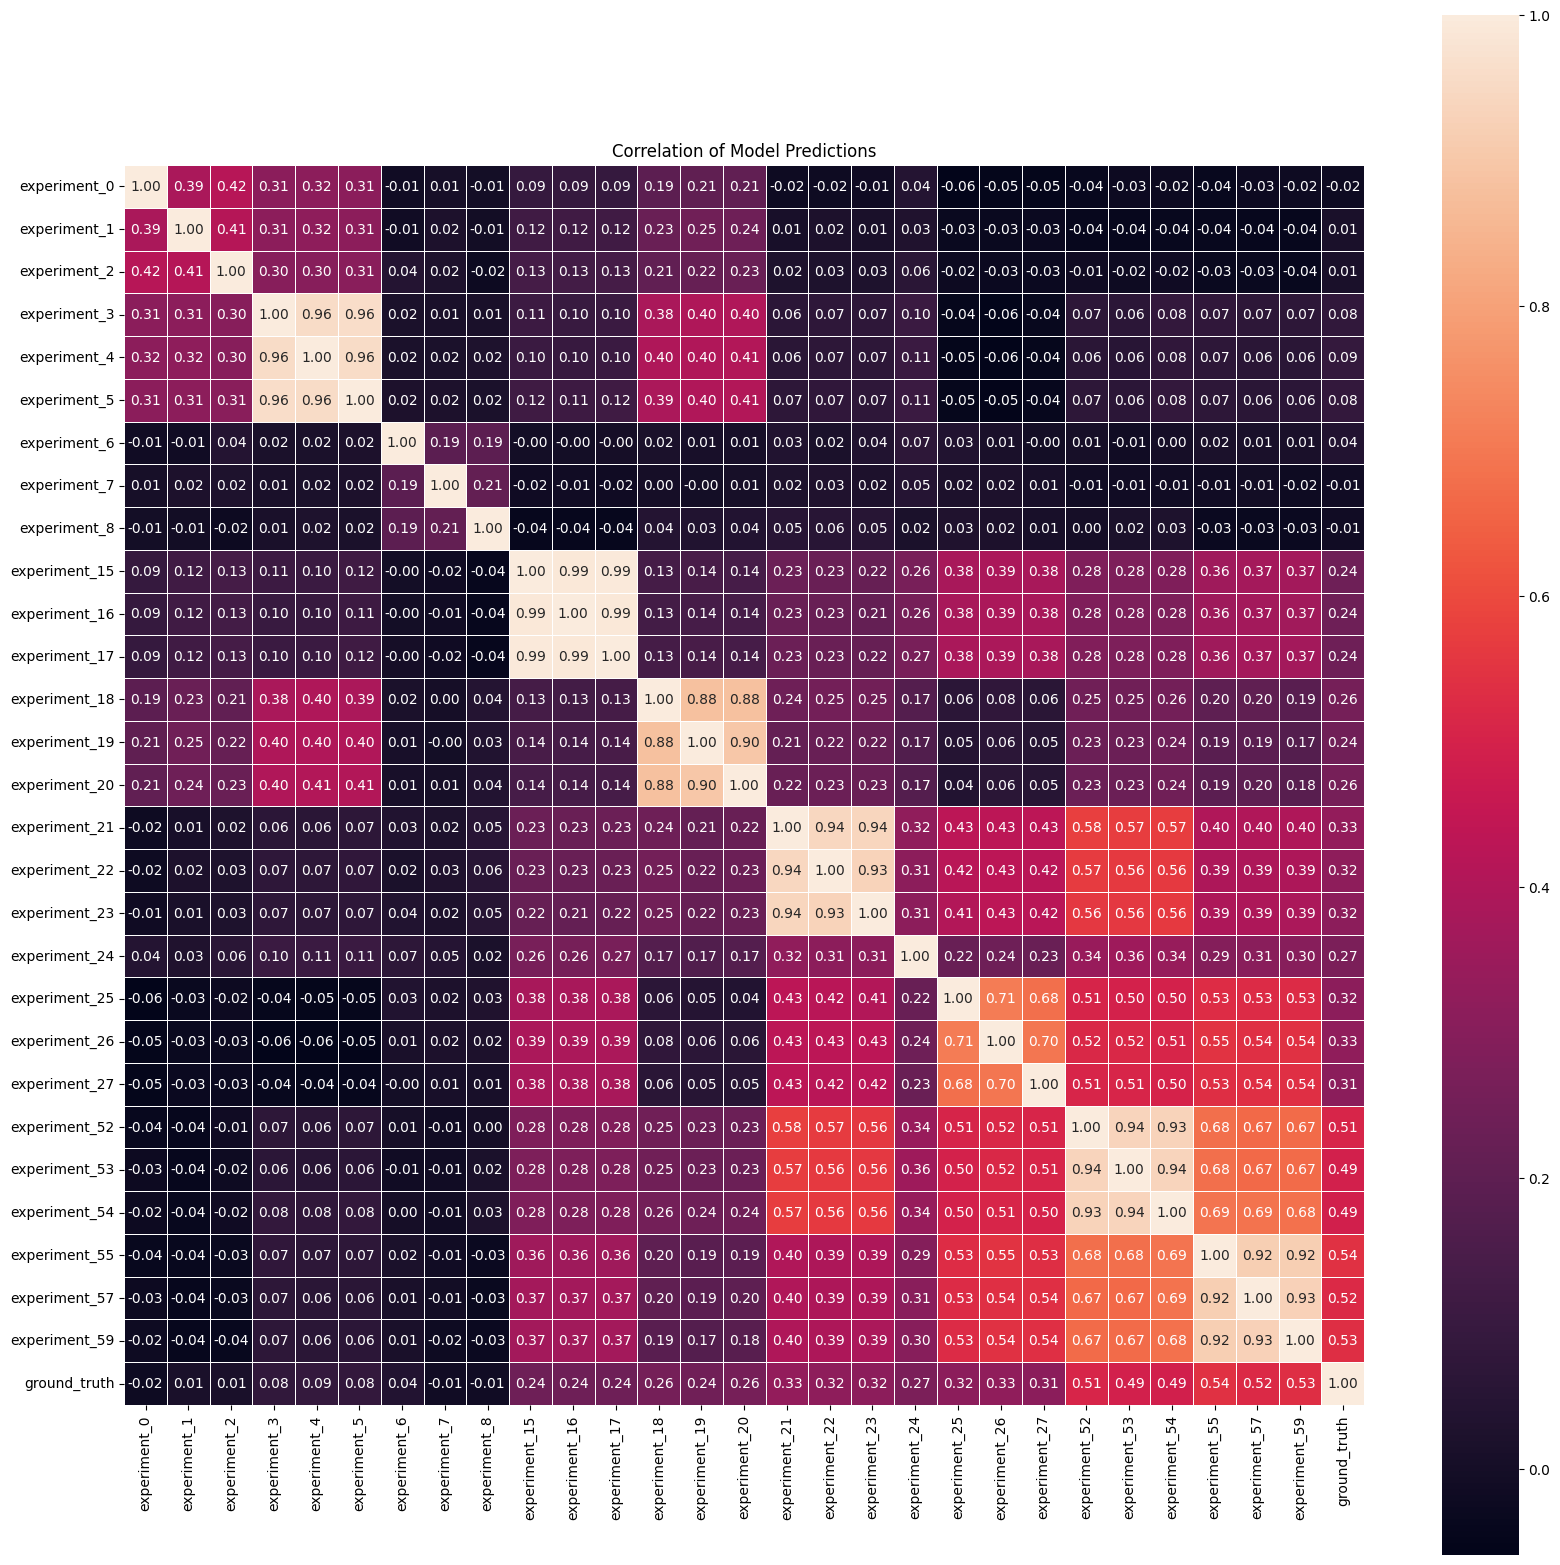

Mapping from short to long names:
experiment_0 => Meta-Llama-3-8B-LOCAL - LOCAL - no quantization - naive zero-shot - 1
experiment_1 => Meta-Llama-3-8B-LOCAL - LOCAL - no quantization - naive zero-shot - 2
experiment_2 => Meta-Llama-3-8B-LOCAL - LOCAL - no quantization - naive zero-shot - 3
experiment_3 => Mistral-7B-Instruct-LOCAL - LOCAL - no quantization - naive zero-shot - 1
experiment_4 => Mistral-7B-Instruct-LOCAL - LOCAL - no quantization - naive zero-shot - 2
experiment_5 => Mistral-7B-Instruct-LOCAL - LOCAL - no quantization - naive zero-shot - 3
experiment_6 => Equall/Saul-7B-Instruct-LOCAL - LOCAL - no quantization - naive zero-shot - 1
experiment_7 => Equall/Saul-7B-Instruct-LOCAL - LOCAL - no quantization - naive zero-shot - 2
experiment_8 => Equall/Saul-7B-Instruct-LOCAL - LOCAL - no quantization - naive zero-shot - 3
experiment_15 => Mixtral-8x7B-Instruct-LOCAL - LOCAL - normal - naive zero-shot - 1
experiment_16 => Mixtral-8x7B-Instruct-LOCAL - LOCAL - normal - naive ze

In [10]:
from MachineLearning.plotting import plot_CorrelationHeatmap

plot_CorrelationHeatmap(df_preds, name_map)

# Comparing Classifier Agreement

When comparing how similarly two classifiers (or “raters”) label the same set of items, two common metrics are used:

## 1. Simple Agreement

- **Definition:**  
  The fraction of instances where both classifiers assign the same label.  
  It is expressed as a proportion between 0 and 1.

- **Limitations:**  
  - Does not account for class imbalance.  
  - Ignores the possibility of chance-level agreement.  
  - For example, if both models always predict the most frequent class, the agreement might be high even though no meaningful discrimination is happening.

## 2. Cohen’s Kappa

- **Definition:**  
  An inter-rater reliability measure that adjusts for the agreement expected by chance.

- **Value Range:**  
  - **+1:** Perfect agreement.
  - **0:** Agreement equivalent to random guessing.
  - **Negative values:** Agreement worse than what would be expected by chance.

- **Interpretation:**  
  Cohen’s Kappa measures how much better (or worse) the observed agreement is compared to random guessing, given the classifiers' label distributions.
  - If two models heavily favor the same classes, simple agreement might be high, but Kappa will reveal that much of this agreement is due to class imbalance.
  - Conversely, if the models do not share the same biases, a higher Kappa indicates that their agreement is genuinely above chance levels.

## Usage Considerations

- **Simple Agreement:**  
  Straightforward to compute but can be misleading on unbalanced datasets.

- **Cohen’s Kappa:**  
  Provides a more nuanced view of model performance, especially useful when dealing with unbalanced datasets or when the models have strong prior biases.

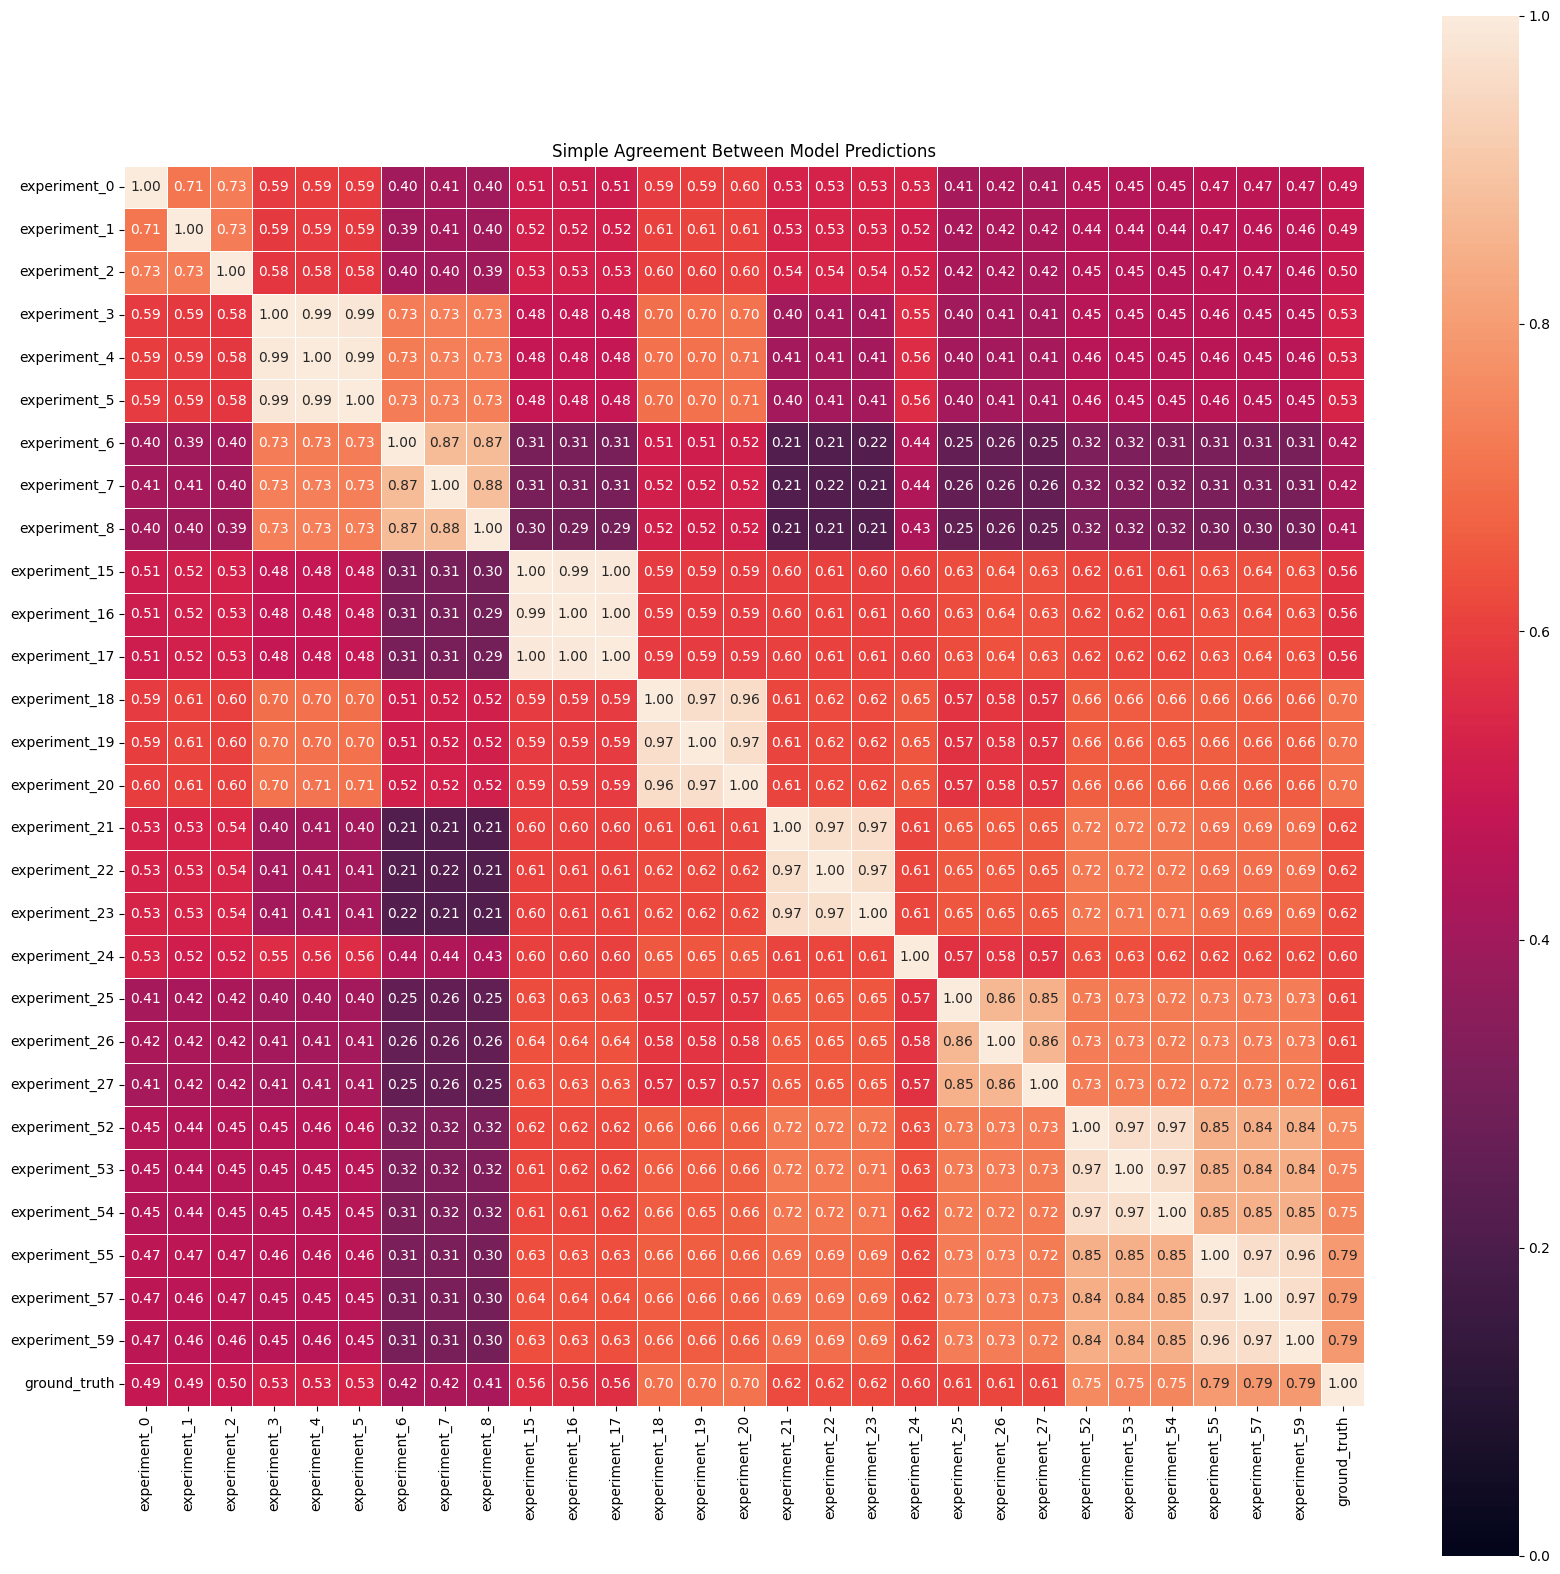

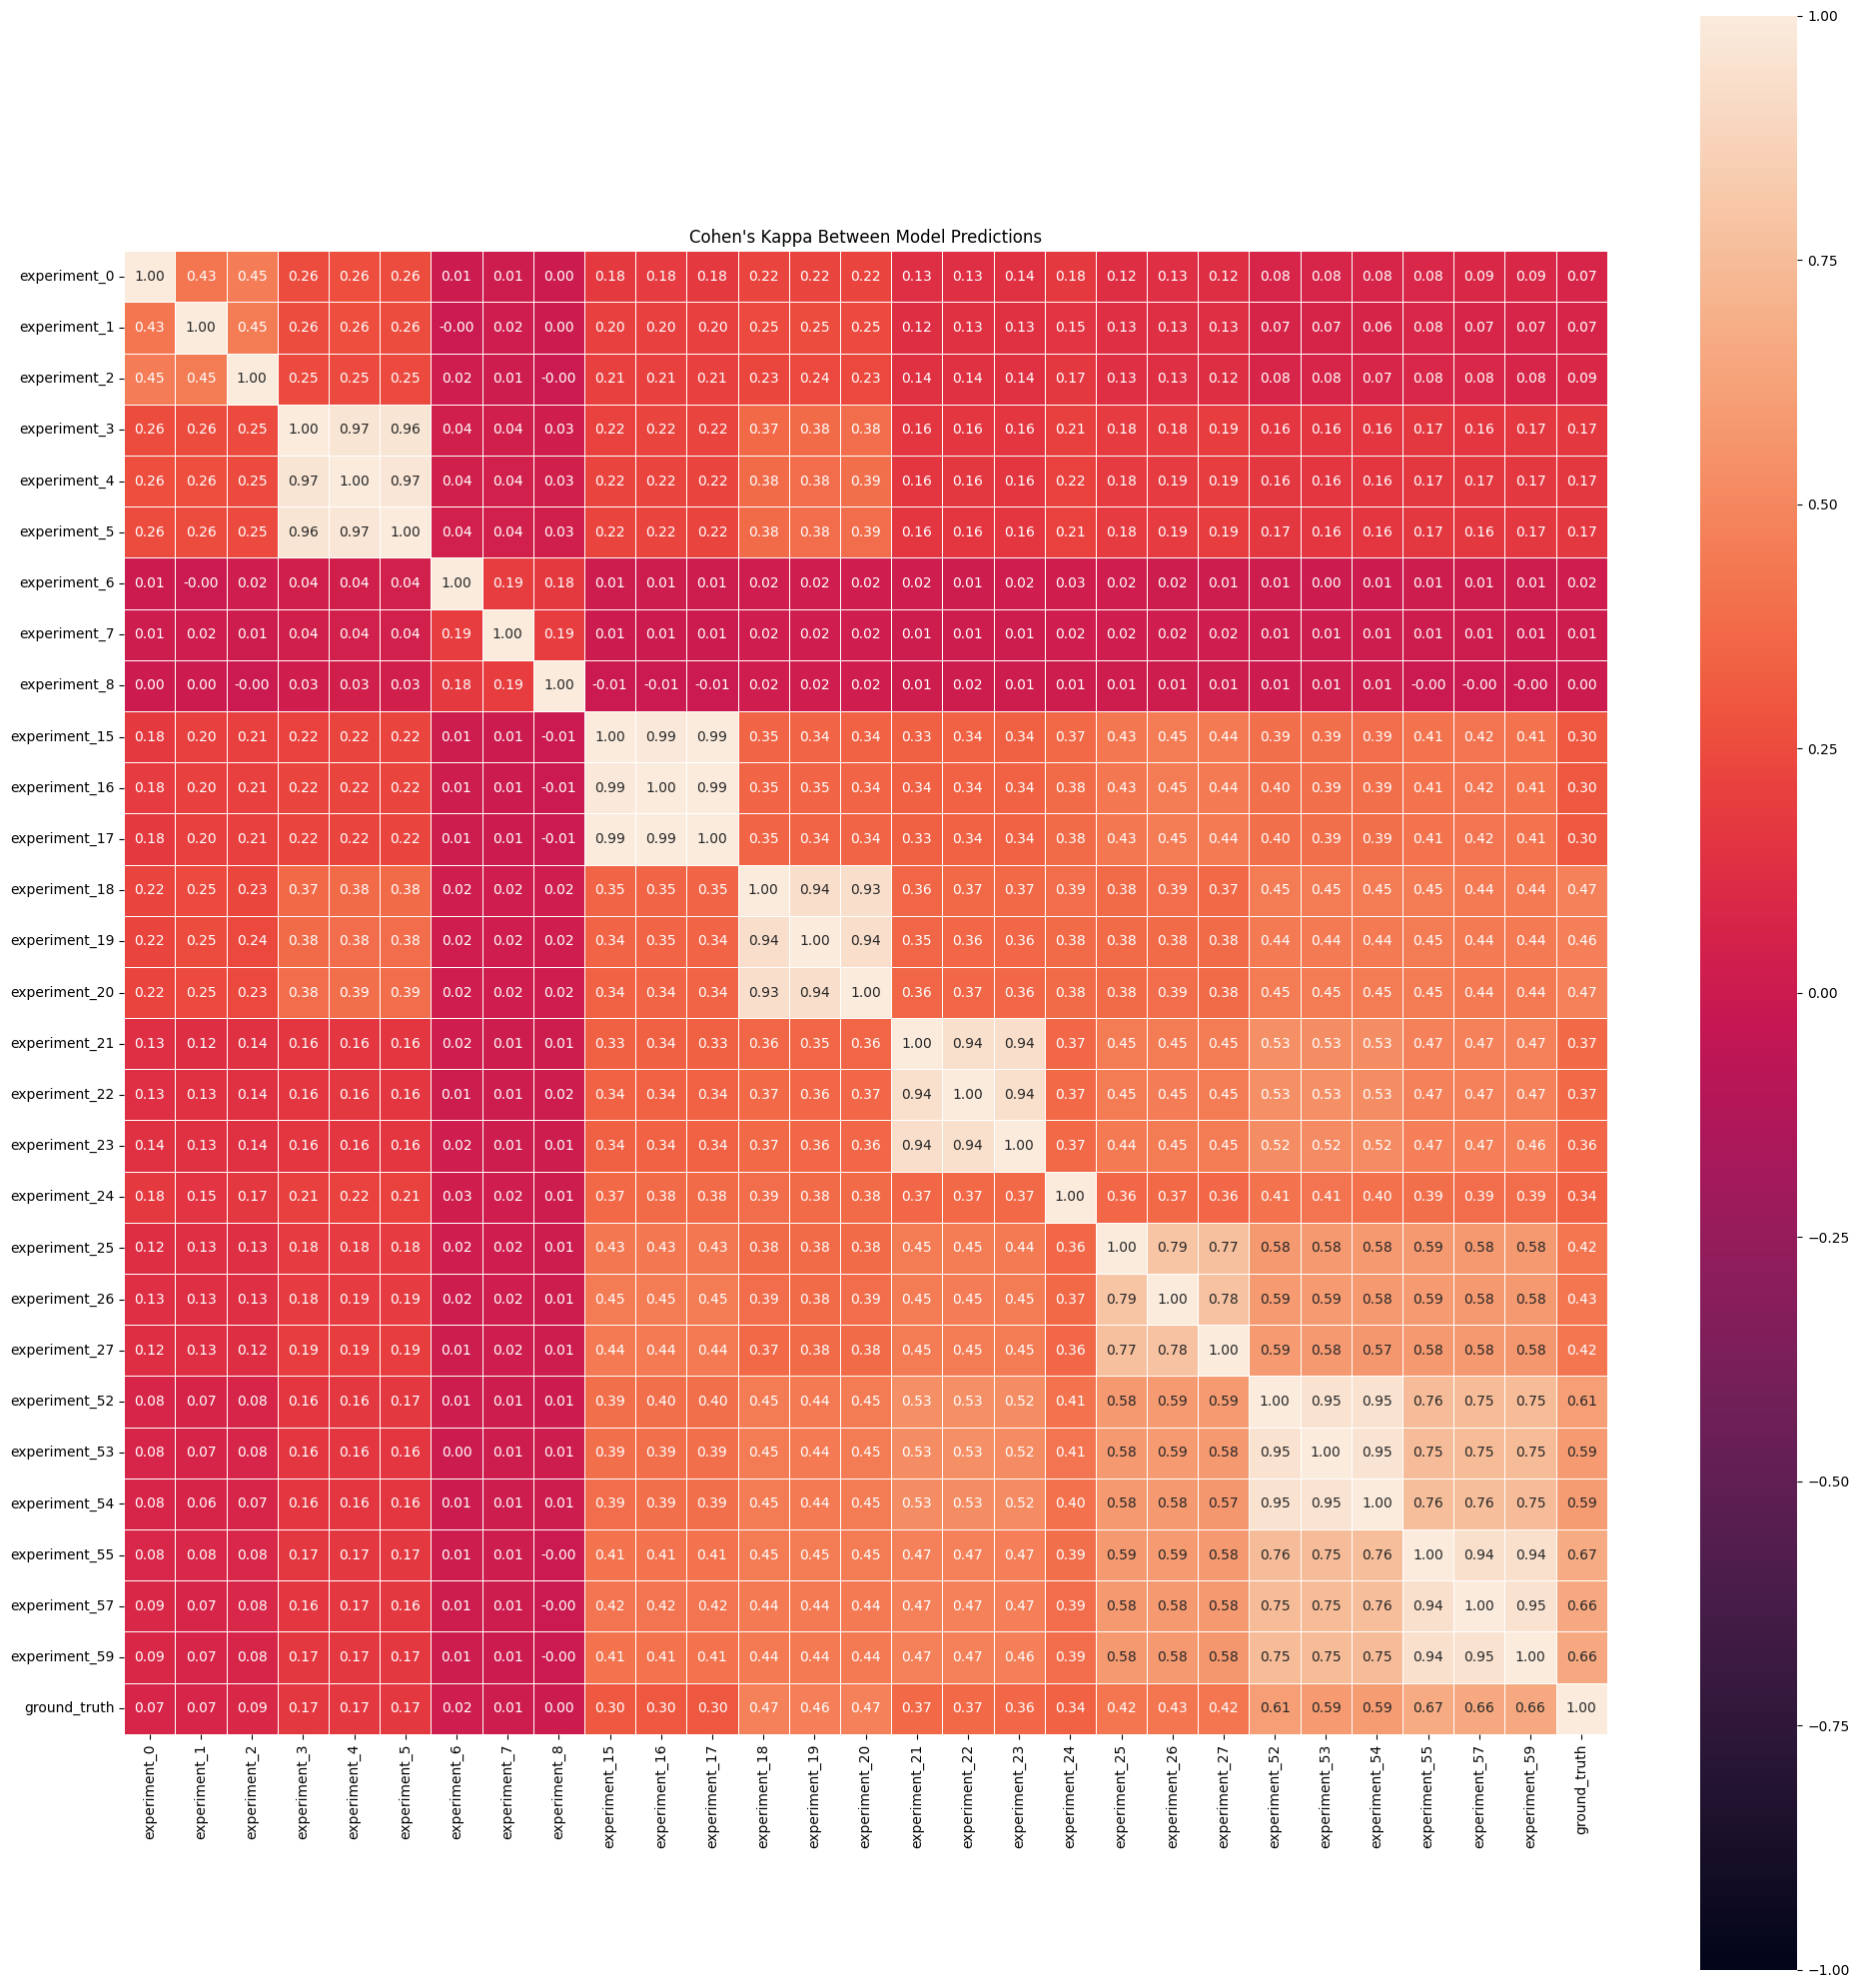

In [11]:
from MachineLearning.plotting import plot_agreement_heatmaps

plot_agreement_heatmaps(df_preds)

Data split into train set (1672 samples) and test set (419 samples)
Initial class distribution in TRAIN: Counter({1: 774, 2: 722, 0: 176})
Initial class distribution in TEST: Counter({1: 194, 2: 181, 0: 44})

Performing grid search for LogisticRegression...
Fitting 5 folds for each of 120 candidates, totalling 600 fits


/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_

Best LogisticRegression score: 0.763

Performing grid search for DecisionTreeClassifier...
Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best DecisionTreeClassifier score: 0.829

Performing grid search for RandomForestClassifier...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Best RandomForestClassifier score: 0.845

Performing grid search for GradientBoostingClassifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best GradientBoostingClassifier score: 0.832

Performing grid search for SVC...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best SVC score: 0.825

Performing grid search for MLPClassifier...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best MLPClassifier score: 0.812

Performing grid search for GaussianNB...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best GaussianNB score: 0.777

Performing grid search for KNeighborsClassifier...
Fitting 5 folds for each of 30 cand

/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_

Results logged to results/logs/meta_learning_results_20250303_120018.json
Metrics summary written to results/logs/metrics_summary_20250303_120018.txt
Metrics CSV file written to results/logs/metrics_20250303_120018.csv


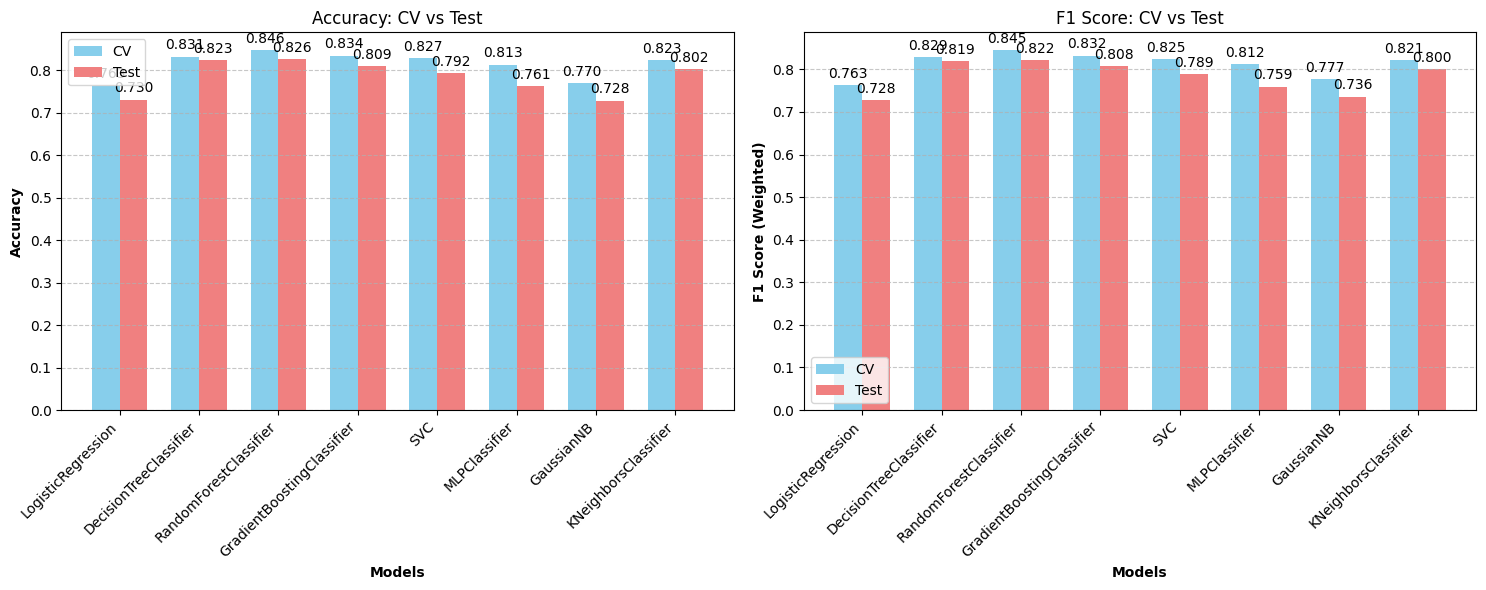

CV vs Test comparison plot saved to results/plots/cv_test_comparison_20250303_120023.png


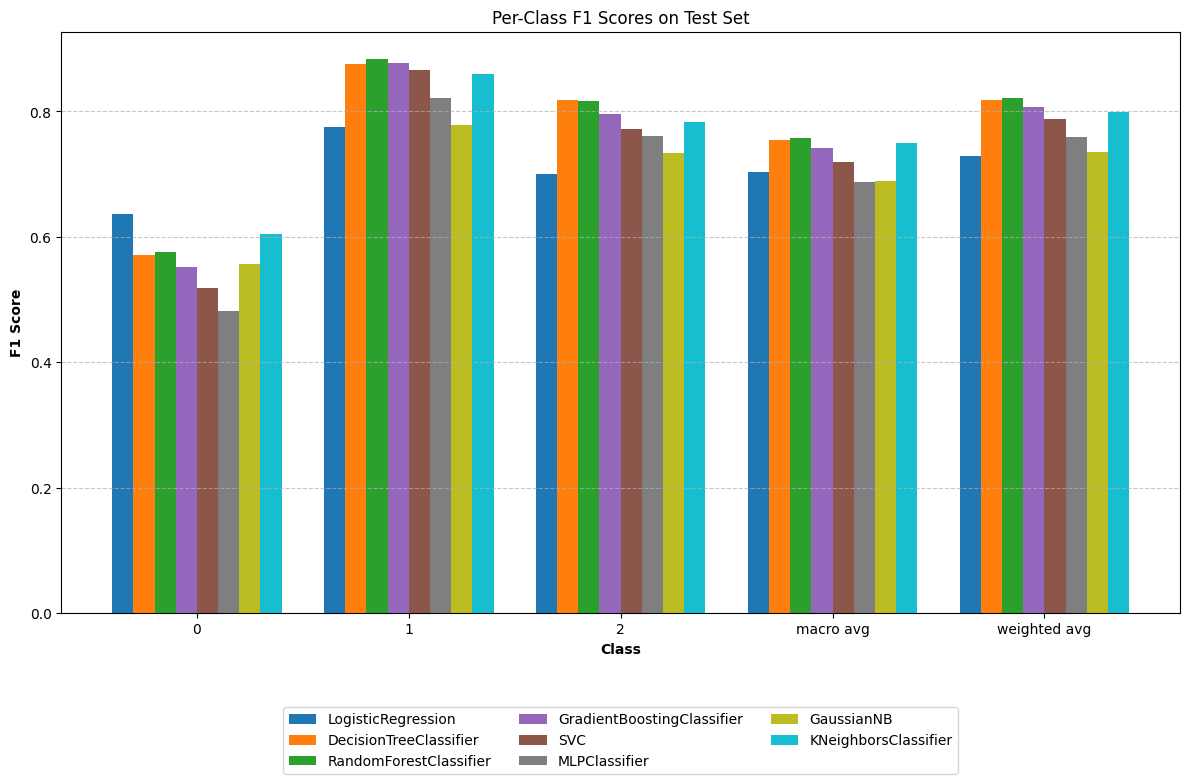

Per-class F1 scores plot saved to results/plots/per_class_f1_test_20250303_120023.png

Meta-learning pipeline completed!


In [12]:
from MachineLearning.metaLearning import meta_learning

overall_best_model, best_models, metrics = meta_learning(df_preds)

Data split into train set (1672 samples) and test set (419 samples)
Initial class distribution in TRAIN: Counter({1: 774, 2: 722, 0: 176})
Initial class distribution in TEST: Counter({1: 194, 2: 181, 0: 44})

---- PCA Dimensionality Reduction ----
Features before PCA: 28
Number of components to reach 95% variance: 14


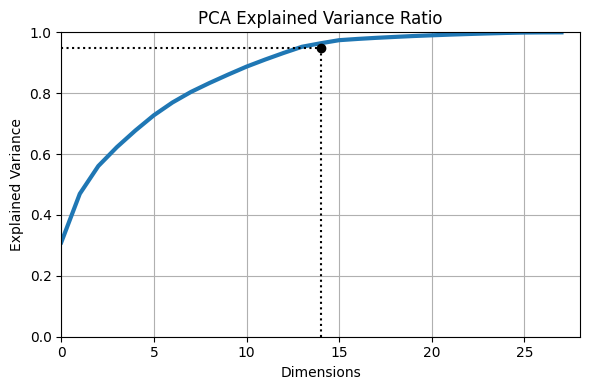


Performing grid search for LogisticRegression...
Fitting 5 folds for each of 120 candidates, totalling 600 fits


/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_

Best LogisticRegression score: 0.764

Performing grid search for DecisionTreeClassifier...
Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best DecisionTreeClassifier score: 0.787

Performing grid search for RandomForestClassifier...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Best RandomForestClassifier score: 0.825

Performing grid search for GradientBoostingClassifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best GradientBoostingClassifier score: 0.816

Performing grid search for SVC...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best SVC score: 0.821

Performing grid search for MLPClassifier...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best MLPClassifier score: 0.809

Performing grid search for GaussianNB...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best GaussianNB score: 0.749

Performing grid search for KNeighborsClassifier...
Fitting 5 folds for each of 30 cand

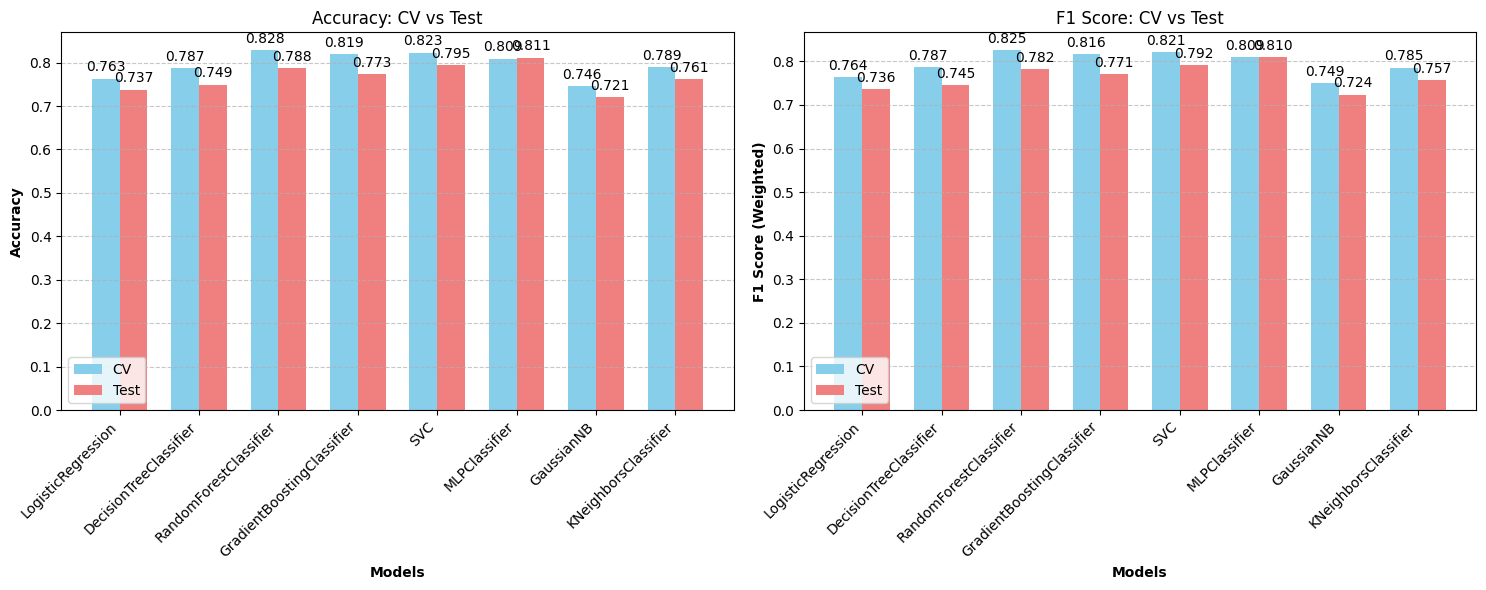

CV vs Test comparison plot saved to results_pca/plots/cv_test_comparison_20250303_121929.png


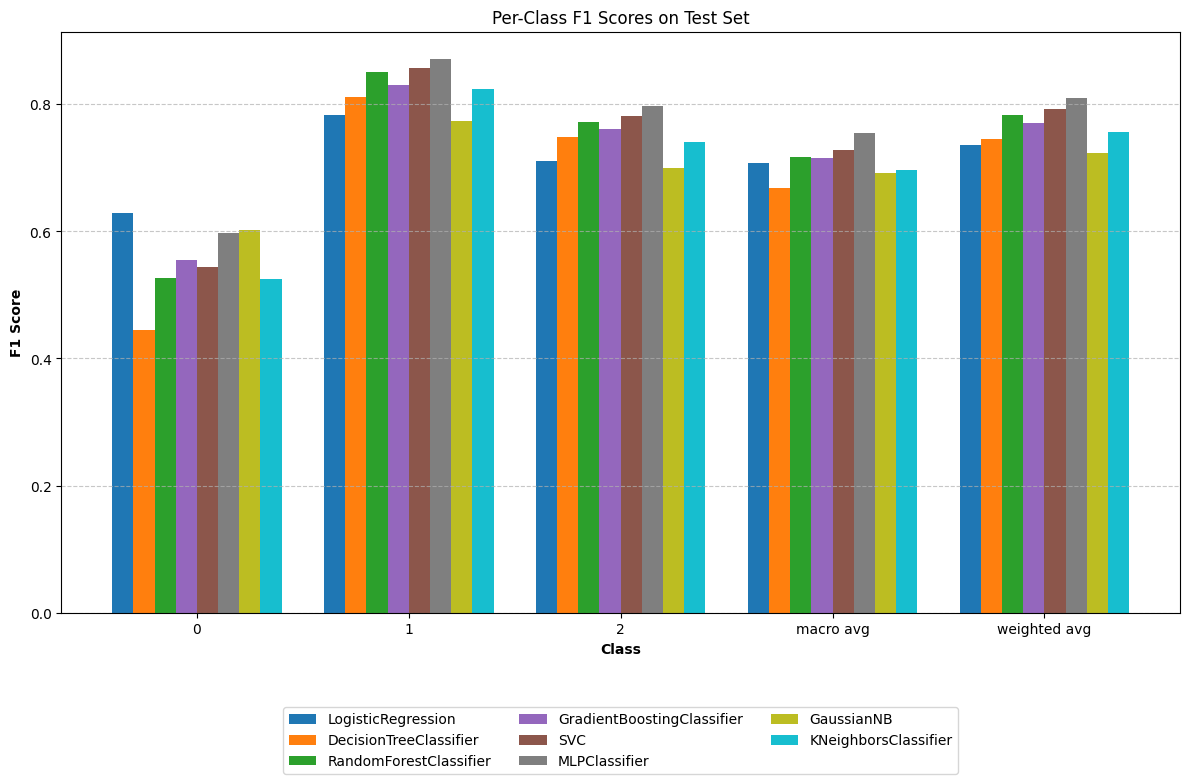

Per-class F1 scores plot saved to results_pca/plots/per_class_f1_test_20250303_121929.png

Meta-learning pipeline completed!


In [13]:
overall_best_model, best_models, metrics = meta_learning(
    df_preds, 
    test_size=0.2,
    save_dir="results_pca",
    use_pca=True,
    pca_variance_threshold=0.95
)

Data split into train set (1672 samples) and test set (419 samples)
Initial class distribution in TRAIN: Counter({1: 774, 2: 722, 0: 176})
Initial class distribution in TEST: Counter({1: 194, 2: 181, 0: 44})

---- Oversampling training data ----
Class distribution after SMOTE: Counter({2: 774, 0: 774, 1: 774})

Performing grid search for LogisticRegression...
Fitting 5 folds for each of 120 candidates, totalling 600 fits


/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_

Best LogisticRegression score: 0.780

Performing grid search for DecisionTreeClassifier...
Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best DecisionTreeClassifier score: 0.846

Performing grid search for RandomForestClassifier...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Best RandomForestClassifier score: 0.865

Performing grid search for GradientBoostingClassifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best GradientBoostingClassifier score: 0.858

Performing grid search for SVC...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best SVC score: 0.846

Performing grid search for MLPClassifier...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best MLPClassifier score: 0.836

Performing grid search for GaussianNB...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best GaussianNB score: 0.794

Performing grid search for KNeighborsClassifier...
Fitting 5 folds for each of 30 cand

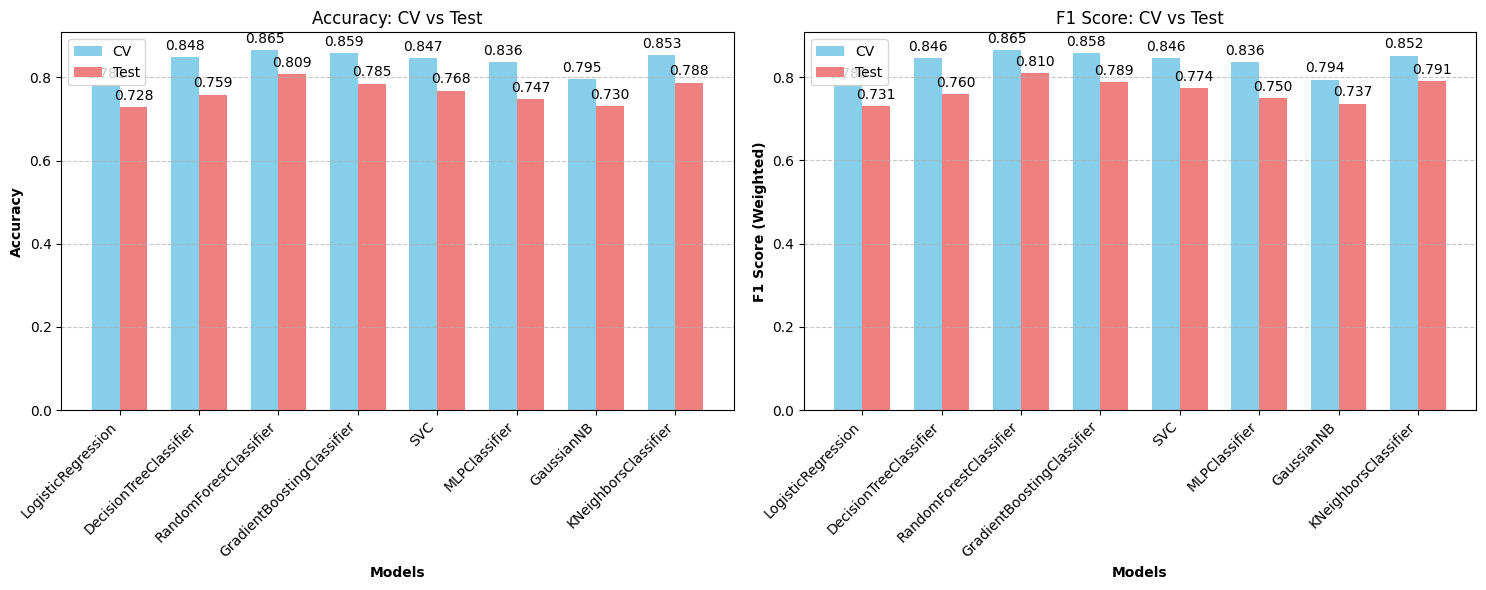

CV vs Test comparison plot saved to results_oversampling/plots/cv_test_comparison_20250303_123030.png


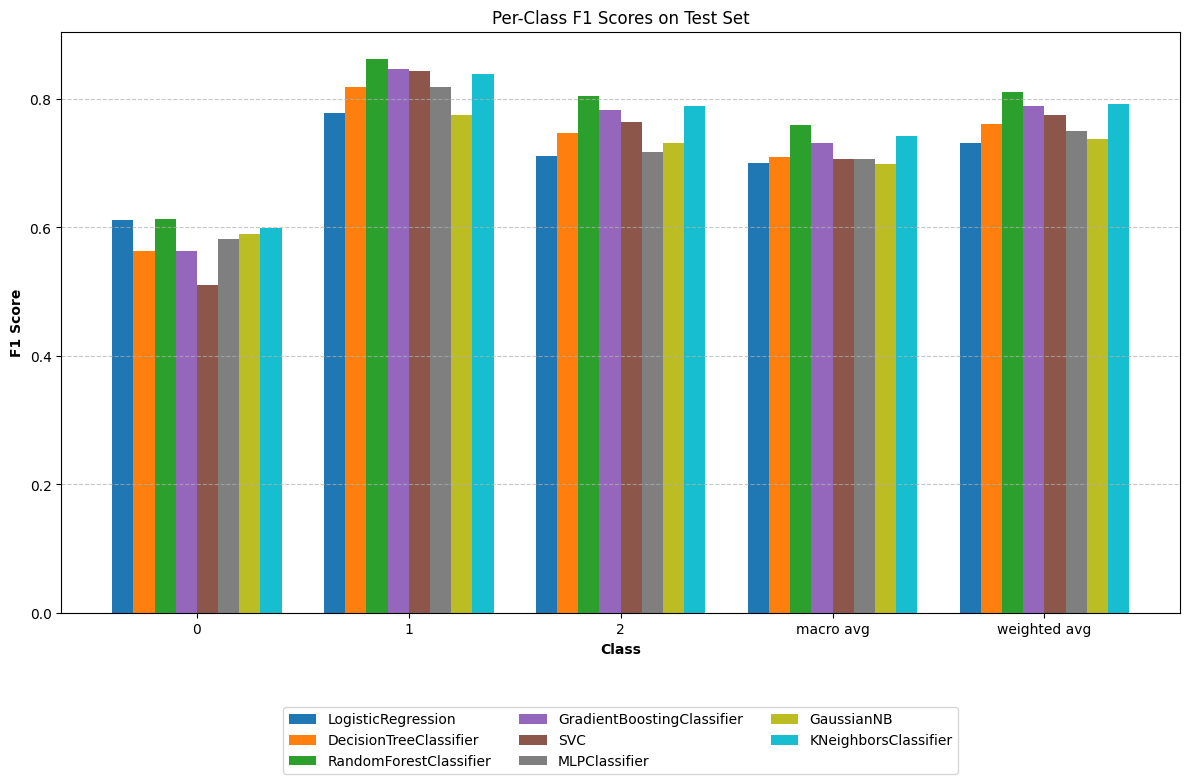

Per-class F1 scores plot saved to results_oversampling/plots/per_class_f1_test_20250303_123030.png

Meta-learning pipeline completed!


In [14]:
# # With oversampling:
overall_best, best_models, model_metrics = meta_learning(
    df_preds,
    test_size=0.2,
    save_dir="results_oversampling",
    use_pca=False,
    do_oversample=True
)

Data split into train set (1672 samples) and test set (419 samples)
Initial class distribution in TRAIN: Counter({1: 774, 2: 722, 0: 176})
Initial class distribution in TEST: Counter({1: 194, 2: 181, 0: 44})

---- Undersampling training data ----
Class distribution before undersampling: Counter({1: 774, 2: 722, 0: 176})
Class distribution after undersampling: Counter({0: 176, 1: 176, 2: 176})

Performing grid search for LogisticRegression...
Fitting 5 folds for each of 120 candidates, totalling 600 fits


/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/petrosrapto/Desktop/DiplomaThesis/DiplomaThesis/venv/lib/python3.11/site-packages/sklearn/linear_

Best LogisticRegression score: 0.750

Performing grid search for DecisionTreeClassifier...
Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best DecisionTreeClassifier score: 0.814

Performing grid search for RandomForestClassifier...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Best RandomForestClassifier score: 0.813

Performing grid search for GradientBoostingClassifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best GradientBoostingClassifier score: 0.807

Performing grid search for SVC...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best SVC score: 0.785

Performing grid search for MLPClassifier...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best MLPClassifier score: 0.764

Performing grid search for GaussianNB...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best GaussianNB score: 0.784

Performing grid search for KNeighborsClassifier...
Fitting 5 folds for each of 30 cand

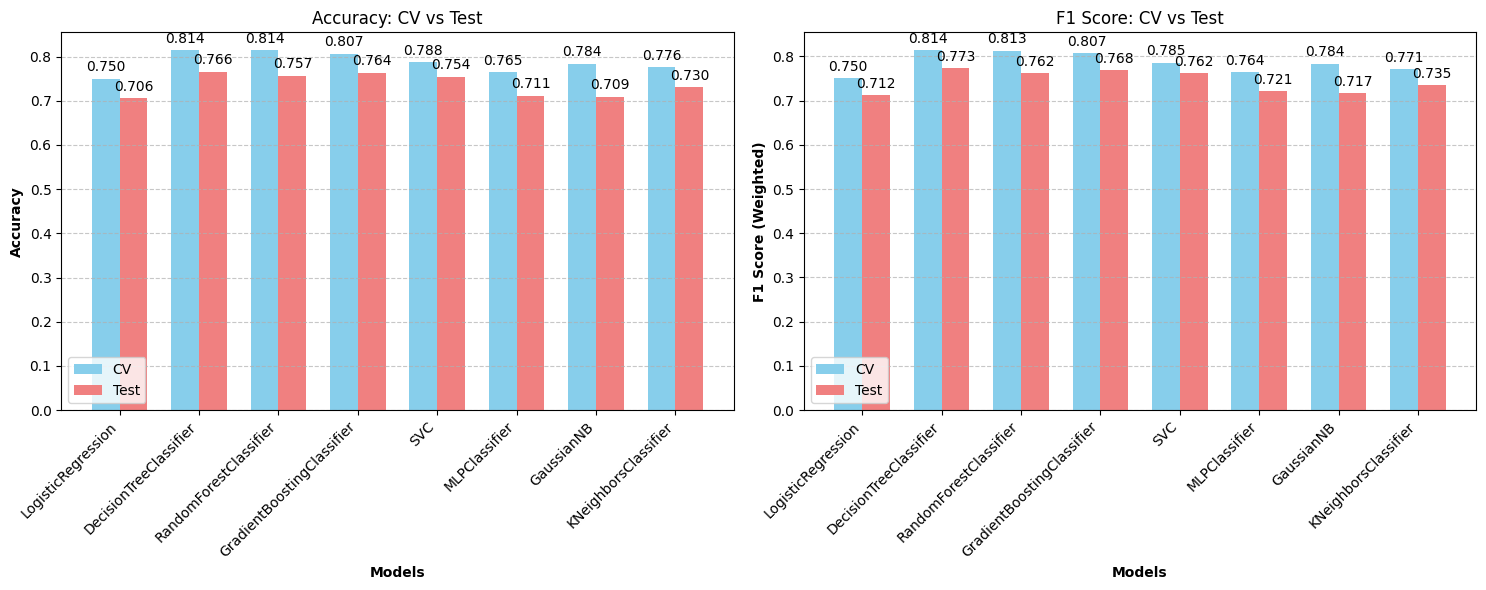

CV vs Test comparison plot saved to results_undersampling/plots/cv_test_comparison_20250303_123447.png


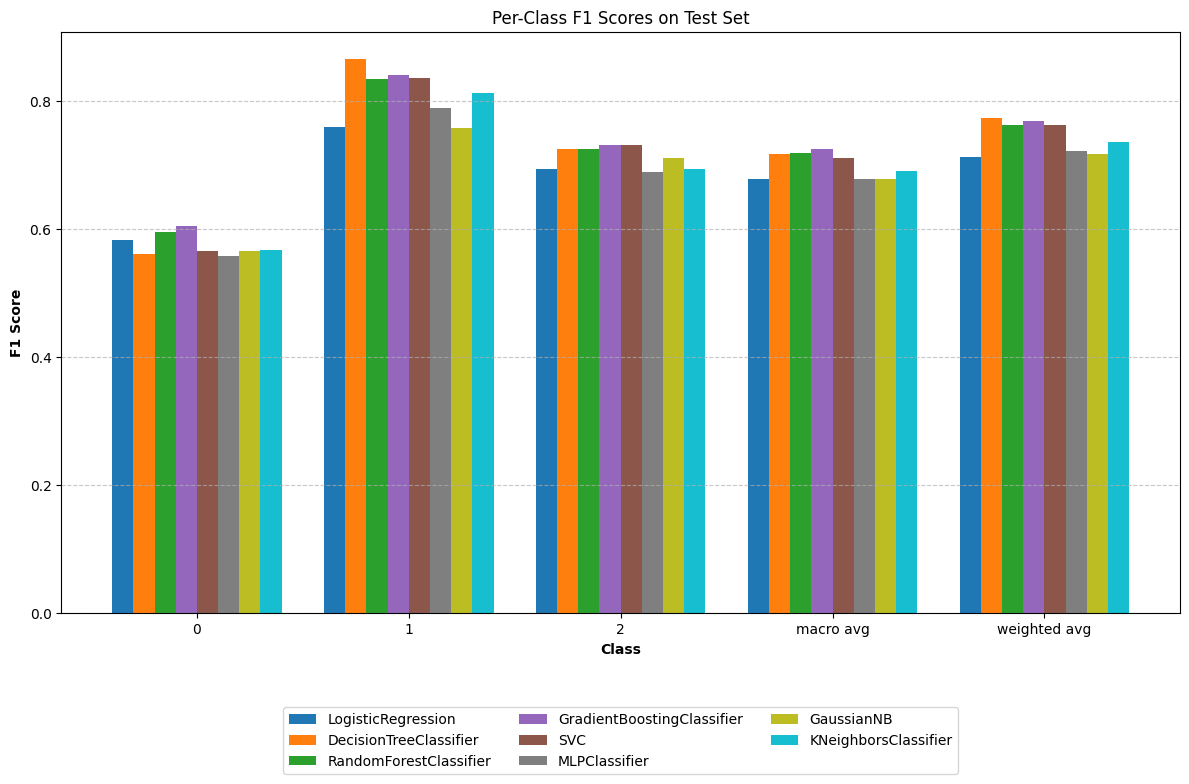

Per-class F1 scores plot saved to results_undersampling/plots/per_class_f1_test_20250303_123447.png

Meta-learning pipeline completed!


In [15]:
# # With undersampling:
overall_best, best_models, model_metrics = meta_learning(
    df_preds,
    test_size=0.2,
    save_dir="results_undersampling",
    use_pca=False,
    do_undersample=True
)

In [24]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score
from MachineLearning.preprocessing import prepare_data

# Create a VotingClassifier using pre-trained models
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in best_models.items()],
    voting='hard'  # Use 'soft' if models support predict_proba()
)

# Prepare train-test split
X_train, X_test, y_train, y_test = prepare_data(df_preds)

# Train the VotingClassifier (it needs to be trained to work)
voting_clf.fit(X_train, y_train)

# Predict using the trained VotingClassifier
y_pred_voting = voting_clf.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_voting)
f1_weighted = f1_score(y_test, y_pred_voting, average='weighted')

# Print results
print(f"Voting Classifier Accuracy: {accuracy:.4f}")
print(f"Voting Classifier F1-Weighted Score: {f1_weighted:.4f}")

Voting Classifier Accuracy: 0.7924
Voting Classifier F1-Weighted Score: 0.7891


In [27]:
import numpy as np
from scipy.stats import mode
from sklearn.metrics import accuracy_score, f1_score
from MachineLearning.preprocessing import prepare_data

# Prepare train-test split
X_train, X_test, y_train, y_test = prepare_data(df_preds)

# ---- HARD VOTING (Majority Rule) ----
# Get predictions from each trained model
all_preds = np.column_stack([model.predict(X_test) for model in best_models.values()])

# Compute the most common prediction per sample (Majority Vote)
# Note: In newer scipy versions, mode() returns a ModeResult object
# The correct way to access the mode depends on your scipy version
try:
    # For newer scipy versions (≥1.9.0)
    y_pred_hard = mode(all_preds, axis=1, keepdims=False)[0]
except TypeError:
    # For older scipy versions
    y_pred_hard = mode(all_preds, axis=1)[0].flatten()

# Evaluate Hard Voting performance
accuracy_hard = accuracy_score(y_test, y_pred_hard)
f1_weighted_hard = f1_score(y_test, y_pred_hard, average='weighted')

# ---- SOFT VOTING (Probability Averaging) ----
soft_voting_models = [model for model in best_models.values() if hasattr(model, "predict_proba")]

if soft_voting_models:
    # Check if classes are consistent across models
    # This is important if models were trained on different class orders
    first_model_classes = None
    for model in soft_voting_models:
        if hasattr(model, 'classes_'):
            if first_model_classes is None:
                first_model_classes = model.classes_
            elif not np.array_equal(model.classes_, first_model_classes):
                print("Warning: Models have different class orderings. Soft voting may produce incorrect results.")
                break

    # Get probability predictions from models that support predict_proba()
    all_probs = np.array([model.predict_proba(X_test) for model in soft_voting_models])
    
    # Average the probabilities across models
    avg_probs = np.mean(all_probs, axis=0)

    # Choose the class with the highest average probability
    y_pred_soft = np.argmax(avg_probs, axis=1)
    
    # Convert from indices to actual class labels if classes_ is available
    if hasattr(soft_voting_models[0], 'classes_'):
        y_pred_soft = soft_voting_models[0].classes_[y_pred_soft]

    # Evaluate Soft Voting performance
    accuracy_soft = accuracy_score(y_test, y_pred_soft)
    f1_weighted_soft = f1_score(y_test, y_pred_soft, average='weighted')

    # Print results for Soft Voting
    print("\nSoft Voting Classifier Results:")
    print(f"Accuracy: {accuracy_soft:.4f}")
    print(f"F1-Weighted Score: {f1_weighted_soft:.4f}")
else:
    print("\nNo models support probability distributions. Soft voting skipped.")

# Print results for Hard Voting
print("\nHard Voting Classifier Results:")
print(f"Accuracy: {accuracy_hard:.4f}")
print(f"F1-Weighted Score: {f1_weighted_hard:.4f}")


Soft Voting Classifier Results:
Accuracy: 0.7422
F1-Weighted Score: 0.7478

Hard Voting Classifier Results:
Accuracy: 0.7470
F1-Weighted Score: 0.7530


In [31]:
import numpy as np
import pandas as pd
from scipy.stats import mode
from sklearn.metrics import accuracy_score, f1_score

def apply_voting(df_preds, soft_voting=False):
    """
    Applies hard or soft voting on model predictions.
    
    Parameters:
    - df_preds (pd.DataFrame): DataFrame where columns are model predictions and "ground_truth" (optional) for evaluation.
    - soft_voting (bool): If True, uses probability averaging. If False, uses majority voting.

    Returns:
    - y_voted (np.array): Final predictions after voting.
    - metrics (dict, optional): Accuracy and F1-score if "ground_truth" exists.
    """
    df_models = df_preds.drop(columns=["ground_truth"], errors="ignore")  # Exclude ground truth if exists
    
    # Check if we have probability distributions (for soft voting)
    if soft_voting and isinstance(df_models.iloc[0, 0], (list, np.ndarray)):
        # Soft Voting: Average probability distributions
        avg_probs = np.mean(np.stack(df_models.applymap(np.array).values), axis=1)  
        y_voted = np.argmax(avg_probs, axis=1)
    else:
        # Hard Voting: Majority rule
        y_voted = mode(df_models.values, axis=1).mode.flatten()

    # Evaluate if ground truth exists
    metrics = {}
    if "ground_truth" in df_preds:
        y_true = df_preds["ground_truth"].values
        metrics["accuracy"] = accuracy_score(y_true, y_voted)
        metrics["f1_weighted"] = f1_score(y_true, y_voted, average='weighted')

    return y_voted, metrics if metrics else None

In [33]:
y_voted_hard, metrics_hard = apply_voting(df_preds, soft_voting=False)
print("Metrics:", metrics_hard)

Metrics: {'accuracy': 0.7427068388330942, 'f1_weighted': 0.7426342842544235}
